In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully")

Libraries imported successfully


In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [5]:
import zipfile
with zipfile.ZipFile("archive (1).zip", "r") as zip_ref:
    zip_ref.extractall("dataset")
print("Dataset extracted successfully")

Dataset extracted successfully


In [6]:
df = pd.read_csv("dataset/Phishing_Legitimate_full.csv")
print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (10000, 50)


In [7]:
df.head()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


In [8]:
print(df.columns.tolist())

['id', 'NumDots', 'SubdomainLevel', 'PathLevel', 'UrlLength', 'NumDash', 'NumDashInHostname', 'AtSymbol', 'TildeSymbol', 'NumUnderscore', 'NumPercent', 'NumQueryComponents', 'NumAmpersand', 'NumHash', 'NumNumericChars', 'NoHttps', 'RandomString', 'IpAddress', 'DomainInSubdomains', 'DomainInPaths', 'HttpsInHostname', 'HostnameLength', 'PathLength', 'QueryLength', 'DoubleSlashInPath', 'NumSensitiveWords', 'EmbeddedBrandName', 'PctExtHyperlinks', 'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms', 'RelativeFormAction', 'ExtFormAction', 'AbnormalFormAction', 'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch', 'FakeLinkInStatusBar', 'RightClickDisabled', 'PopUpWindow', 'SubmitInfoToEmail', 'IframeOrFrame', 'MissingTitle', 'ImagesOnlyInForm', 'SubdomainLevelRT', 'UrlLengthRT', 'PctExtResourceUrlsRT', 'AbnormalExtFormActionR', 'ExtMetaScriptLinkRT', 'PctExtNullSelfRedirectHyperlinksRT', 'CLASS_LABEL']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  10000 non-null  int64  
 1   NumDots                             10000 non-null  int64  
 2   SubdomainLevel                      10000 non-null  int64  
 3   PathLevel                           10000 non-null  int64  
 4   UrlLength                           10000 non-null  int64  
 5   NumDash                             10000 non-null  int64  
 6   NumDashInHostname                   10000 non-null  int64  
 7   AtSymbol                            10000 non-null  int64  
 8   TildeSymbol                         10000 non-null  int64  
 9   NumUnderscore                       10000 non-null  int64  
 10  NumPercent                          10000 non-null  int64  
 11  NumQueryComponents                  10000 

In [10]:
print(df["CLASS_LABEL"].value_counts())

CLASS_LABEL
1    5000
0    5000
Name: count, dtype: int64


In [11]:
X = df.drop(columns=["id", "CLASS_LABEL"])
y = df["CLASS_LABEL"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 48)
Target shape: (10000,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (8000, 48)
Testing data: (2000, 48)


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9855
Accuracy (%): 98.55000000000001


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



[[986  14]
 [ 15 985]]


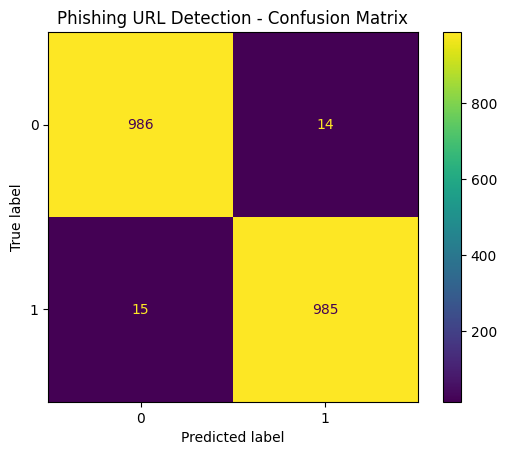

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Phishing URL Detection - Confusion Matrix")
plt.show()

In [17]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

PctExtHyperlinks                      0.206943
PctExtNullSelfRedirectHyperlinksRT    0.167713
FrequentDomainNameMismatch            0.077804
PctExtResourceUrls                    0.067752
PctNullSelfRedirectHyperlinks         0.064520
NumDash                               0.045637
ExtMetaScriptLinkRT                   0.035868
NumNumericChars                       0.033375
InsecureForms                         0.033046
PathLevel                             0.028882
dtype: float64


In [18]:
import joblib

joblib.dump(model, "phishing_url_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [19]:
joblib.dump(list(X.columns), "url_features.pkl")

print("Features saved successfully!")

Features saved successfully!


In [20]:
sample = X_test.iloc[0:5]

predictions = model.predict(sample)

print("Predictions:", predictions)
print("Actual:", y_test.iloc[0:5].values)

Predictions: [0 1 0 1 0]
Actual: [0 1 0 1 0]


In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 98.55000000000001 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



Confusion Matrix:
[[986  14]
 [ 15 985]]


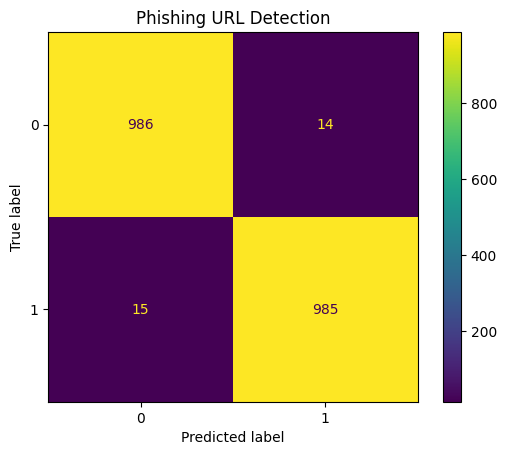

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Phishing URL Detection")
plt.show()

In [23]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

Top 10 Important Features:
PctExtHyperlinks                      0.206943
PctExtNullSelfRedirectHyperlinksRT    0.167713
FrequentDomainNameMismatch            0.077804
PctExtResourceUrls                    0.067752
PctNullSelfRedirectHyperlinks         0.064520
NumDash                               0.045637
ExtMetaScriptLinkRT                   0.035868
NumNumericChars                       0.033375
InsecureForms                         0.033046
PathLevel                             0.028882
dtype: float64


In [24]:
import joblib

joblib.dump(model, "phishing_url_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [25]:
joblib.dump(list(X.columns), "url_features.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [26]:
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")

Accuracy: 98.55000000000001 %


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[986  14]
 [ 15 985]]


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [30]:
import joblib

joblib.dump(model, "phishing_url_model.pkl")

print("Model saved successfully")

Model saved successfully


In [31]:
print("Final Model Accuracy:", round(accuracy * 100, 2), "%")

Final Model Accuracy: 98.55 %


In [32]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

PctExtHyperlinks                      0.206943
PctExtNullSelfRedirectHyperlinksRT    0.167713
FrequentDomainNameMismatch            0.077804
PctExtResourceUrls                    0.067752
PctNullSelfRedirectHyperlinks         0.064520
NumDash                               0.045637
ExtMetaScriptLinkRT                   0.035868
NumNumericChars                       0.033375
InsecureForms                         0.033046
PathLevel                             0.028882
dtype: float64


In [33]:
print("====================================")
print("PHISHING URL DETECTION USING ML")
print("====================================")
print("Algorithm : Random Forest")
print("Dataset   : 10,000 records")
print("Features  : 48")
print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Status    : Model trained successfully")
print("====================================")

PHISHING URL DETECTION USING ML
Algorithm : Random Forest
Dataset   : 10,000 records
Features  : 48
Accuracy  : 98.55 %
Status    : Model trained successfully
